In [3]:
import pandas as pd

df = pd.read_csv("netflix_titles_featured.csv")

print(df.columns.tolist())

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'Content_Length_Category', 'Content_Age', 'Decade', 'Genre_Count']


In [4]:
df.isnull().sum()

show_id                    0
type                       0
title                      0
director                   0
cast                       0
country                    0
date_added                 0
release_year               0
rating                     0
duration                   0
listed_in                  0
description                0
Content_Length_Category    0
Content_Age                0
Decade                     0
Genre_Count                0
dtype: int64

In [5]:
df[['type','rating','release_year','Content_Length_Category']].head()

,type,rating,release_year,Content_Length_Category
0,Movie,PG-13,2020,Medium
1,TV Show,TV-MA,2021,TV Show
2,TV Show,TV-MA,2021,TV Show
3,TV Show,TV-MA,2021,TV Show
4,TV Show,TV-MA,2021,TV Show


In [6]:
print(df['type'].value_counts())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [7]:
from sklearn.preprocessing import LabelEncoder

df_model = df[['type',
               'rating',
               'release_year',
               'Content_Length_Category',
               'Content_Age',
               'Decade',
               'Genre_Count']].copy()

le_type = LabelEncoder()
le_rating = LabelEncoder()
le_length = LabelEncoder()
le_decade = LabelEncoder()

df_model['type'] = le_type.fit_transform(df_model['type'])
df_model['rating'] = le_rating.fit_transform(df_model['rating'])
df_model['Content_Length_Category'] = le_length.fit_transform(df_model['Content_Length_Category'])
df_model['Decade'] = le_decade.fit_transform(df_model['Decade'])

df_model.head()

,type,rating,release_year,Content_Length_Category,Content_Age,Decade,Genre_Count
0,0,7,2020,1,6,9,1
1,1,11,2021,3,5,9,3
2,1,11,2021,3,5,9,3
3,1,11,2021,3,5,9,2
4,1,11,2021,3,5,9,3


In [8]:
from sklearn.model_selection import train_test_split

X = df_model[['rating',
              'release_year',
              'Content_Length_Category',
              'Content_Age',
              'Decade',
              'Genre_Count']]
y = df_model['type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(7045, 6)
(1762, 6)


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [10]:
from sklearn.metrics import classification_report, confusion_matrix

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1214
           1       1.00      1.00      1.00       548

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762

Confusion Matrix:
[[1214    0]
 [   0  548]]


In [11]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

                   Feature  Importance
2  Content_Length_Category    0.914823
0                   rating    0.055571
3              Content_Age    0.013307
1             release_year    0.009064
4                   Decade    0.004372
5              Genre_Count    0.002862


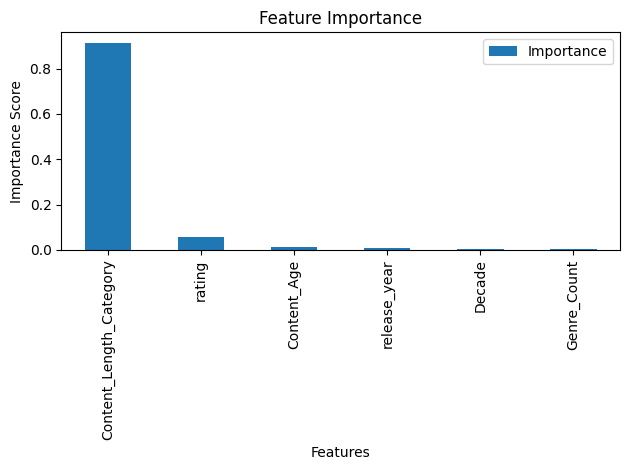

In [12]:
import matplotlib.pyplot as plt

importance.plot(
    x='Feature',
    y='Importance',
    kind='bar'
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [13]:
from sklearn.cluster import KMeans

X_cluster = df_model[['rating', 'release_year', 'Content_Length_Category']]

kmeans = KMeans(n_clusters=3, random_state=42)

df_model['Cluster'] = kmeans.fit_predict(X_cluster)

print(df_model[['rating', 'release_year',
                'Content_Length_Category',
                'Cluster']].head())

   rating  release_year  Content_Length_Category  Cluster
0       7          2020                        1        0
1      11          2021                        3        0
2      11          2021                        3        0
3      11          2021                        3        0
4      11          2021                        3        0


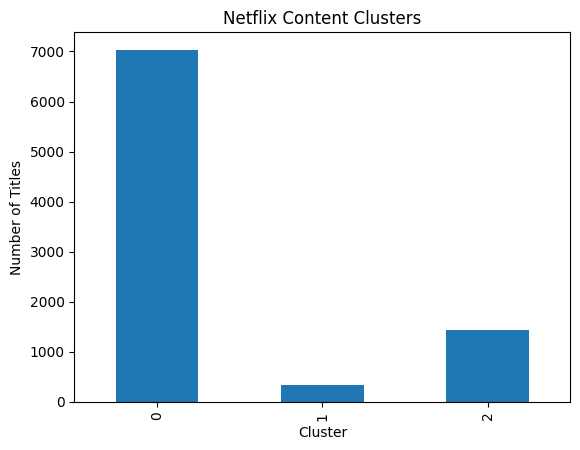

In [14]:
import matplotlib.pyplot as plt

df_model['Cluster'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title("Netflix Content Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Titles")
plt.show()

In [15]:
print(df_model['Cluster'].value_counts())

Cluster
0    7033
2    1433
1     341
Name: count, dtype: int64


In [16]:
print(df['country'].value_counts().head(10))

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [17]:
print(df['listed_in'].value_counts().head(10))

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64
